# Chapter 04 - Regression and Prediction

## Objectives
Learn how regression explains relationships and predicts numeric outcomes. This chapter covers linear regression, multiple regression, residual diagnostics, overfitting, multicollinearity, nonlinear models, and prediction risk.

## Core Theory
Regression estimates how a target variable changes when predictors change. In data science, regression is used for pricing, demand forecasting, risk scoring, salary prediction, and trend modeling.

Important distinction:
- **Explanation**: understand drivers of Y.
- **Prediction**: maximize future accuracy.
These goals may require different models.

In [1]:
import numpy as np, pandas as pd, matplotlib.pyplot as plt, seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import PolynomialFeatures
from sklearn.pipeline import make_pipeline
from sklearn.metrics import mean_squared_error, r2_score
from statsmodels.stats.outliers_influence import variance_inflation_factor
import statsmodels.api as sm
sns.set_theme(style='whitegrid')
np.random.seed(42)

In [2]:
n=300
size=np.random.normal(120,35,n)
rooms=np.random.randint(1,6,n)
age=np.random.randint(0,30,n)
noise=np.random.normal(0,25,n)
price=50+2.8*size+18*rooms-1.4*age+noise
df=pd.DataFrame({'Size':size,'Rooms':rooms,'Age':age,'Price':price})
df.head()

,Size,Rooms,Age,Price
0,137.384995,1,25,419.853868
1,115.160749,4,24,387.166564
2,142.669099,2,14,446.387822
3,173.306045,5,24,536.744061
4,111.804632,1,21,353.031866


## 1. Simple Linear Regression
Model form: **Y = b0 + b1X + error**
- **b0** intercept: expected Y when X=0.
- **b1** slope: expected change in Y for one-unit increase in X.
- Error captures unexplained variation.

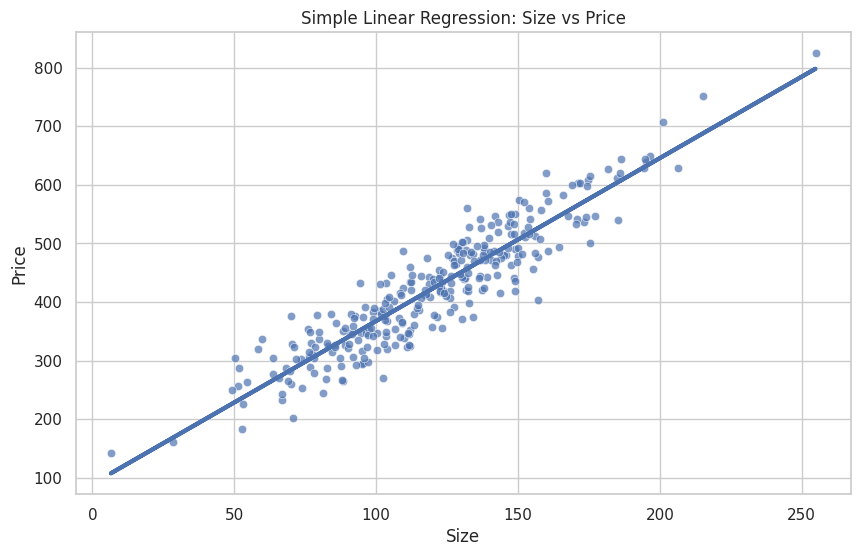

Intercept: 89.63688348184138 Slope: 2.780616429299757


In [3]:
X=df[['Size']]; y=df['Price']
model=LinearRegression().fit(X,y)
pred=model.predict(X)
plt.figure(figsize=(10,6))
sns.scatterplot(data=df,x='Size',y='Price',alpha=.7)
plt.plot(df['Size'],pred,lw=3)
plt.title('Simple Linear Regression: Size vs Price')
plt.show()
print('Intercept:',model.intercept_,'Slope:',model.coef_[0])

## 2. Multiple Linear Regression
Uses several predictors simultaneously. This controls for confounding effects and usually improves predictions.

In [4]:
X=df[['Size','Rooms','Age']]
m2=LinearRegression().fit(X,y)
print('Coefficients:',dict(zip(X.columns,m2.coef_)))
print('Intercept:',m2.intercept_)

Coefficients: {'Size': np.float64(2.760909238674014), 'Rooms': np.float64(17.088422285526708), 'Age': np.float64(-1.4510354383696065)}
Intercept: 60.26471590247684


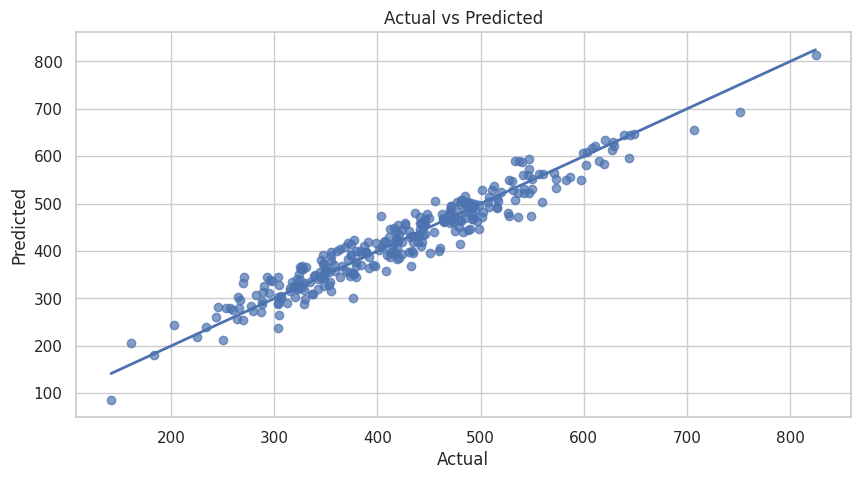

In [5]:
pred2=m2.predict(X)
plt.figure(figsize=(10,5))
plt.scatter(y,pred2,alpha=.7)
plt.plot([y.min(),y.max()],[y.min(),y.max()],lw=2)
plt.xlabel('Actual'); plt.ylabel('Predicted')
plt.title('Actual vs Predicted')
plt.show()

## 3. Residual Analysis
Residual = Actual - Predicted.
Good models tend to have residuals centered near zero with no clear pattern. Patterns may indicate missing variables or nonlinearity.

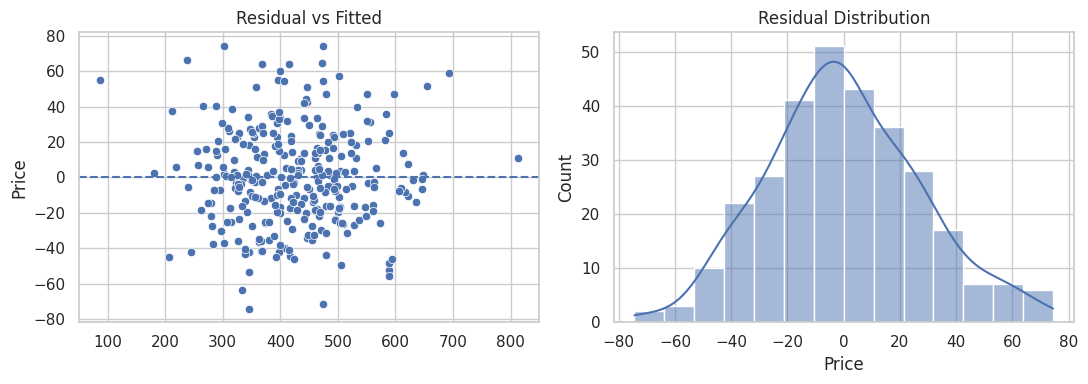

In [6]:
res=y-pred2
fig,ax=plt.subplots(1,2,figsize=(11,4))
sns.scatterplot(x=pred2,y=res,ax=ax[0]); ax[0].axhline(0,ls='--'); ax[0].set_title('Residual vs Fitted')
sns.histplot(res,kde=True,ax=ax[1]); ax[1].set_title('Residual Distribution')
plt.tight_layout(); plt.show()

## 4. Model Metrics
- **R²**: proportion of variance explained.
- **RMSE**: average prediction error magnitude.
Higher R² and lower RMSE are generally better.

In [7]:
print('R2:',r2_score(y,pred2))
mse = mean_squared_error(y, pred2)
rmse = np.sqrt(mse)

print('R2:', r2_score(y, pred2))
print('RMSE:', rmse)

R2: 0.9304267872388885
R2: 0.9304267872388885
RMSE: 27.302636408980856


## 5. Multicollinearity
When predictors are strongly correlated, coefficients become unstable and hard to interpret.

In [8]:
Xv=sm.add_constant(df[['Size','Rooms','Age']])
vif=pd.DataFrame()
vif['Feature']=Xv.columns
vif['VIF']=[variance_inflation_factor(Xv.values,i) for i in range(Xv.shape[1])]
vif

,Feature,VIF
0,const,19.517156
1,Size,1.000813
2,Rooms,1.001745
3,Age,1.000951


## 6. Train/Test Split & Cross Validation
Always validate prediction models on unseen data to reduce overfitting.

In [9]:
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.25,random_state=42)
m3=LinearRegression().fit(X_train,y_train)
p_test=m3.predict(X_test)
print('Test R2:',r2_score(y_test,p_test))
scores=cross_val_score(LinearRegression(),X,y,cv=5,scoring='r2')
print('CV R2 Mean:',scores.mean())

Test R2: 0.8898012826967004
CV R2 Mean: 0.9264673601502477


## 7. Nonlinear Relationship: Polynomial Regression
Some patterns curve rather than straight lines.

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but PolynomialFeatures was fitted with feature names
  warnings.warn(


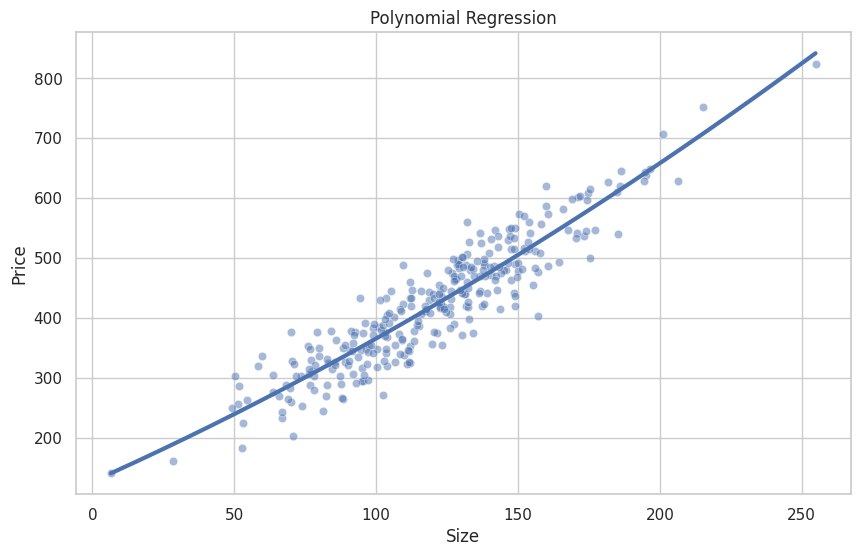

In [10]:
xp=df[['Size']]
poly=make_pipeline(PolynomialFeatures(2),LinearRegression())
poly.fit(xp,y)
grid=np.linspace(df.Size.min(),df.Size.max(),200).reshape(-1,1)
plt.figure(figsize=(10,6))
sns.scatterplot(data=df,x='Size',y='Price',alpha=.5)
plt.plot(grid,poly.predict(grid),lw=3)
plt.title('Polynomial Regression')
plt.show()

## Key Practical Concepts
- Extrapolation outside training range is risky.
- Correlation does not prove causation.
- More variables do not always mean better models.
- Interpretable models are valuable in business contexts.
- Prediction intervals are wider than confidence intervals.

## Key Takeaways
1. Regression can explain and predict.
2. Always inspect residuals, not only R².
3. Validate using test data or cross-validation.
4. Beware multicollinearity and overfitting.
5. Nonlinear relationships may need polynomial/spline models.